In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [9]:
## define state

class BMIState(TypedDict):
    weight_kg: float  # in kilograms
    height_m: float  # in meters
    bmi: float    # Body Mass Index
    

In [10]:
def calculate_bmi(state: BMIState) -> BMIState:
    
    bmi = state['weight_kg'] / (state['height_m'] ** 2)
    state['bmi'] = round(bmi, 2)
    return state

In [ ]:
# ## define your graph
# graph = StateGraph(BMIState)

# ## add nodes to your graph
# graph.add_node("calculate_bmi", calculate_bmi)

# ## add edges to your graph
# graph.add_edge(START, "calculate_bmi")
# graph.add_edge("calculate_bmi", END)

# ## compile the graph
# workflow = graph.compile()

# ## execute the graph
# initial_state= {"weight_kg": 73.25, "height_m": 1.85}
# final_state = workflow.invoke(initial_state)

# print(final_state)

{'weight_kg': 73.25, 'height_m': 1.85, 'bmi': 21.4}


### check whether the user is fit or unfit on the basis of the calculated bmi



In [18]:
## define state

class BMIState(TypedDict):
    weight_kg: float  # in kilograms
    height_m: float  # in meters
    bmi: float    # Body Mass Index
    category: str # BMI Category

In [23]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'

    return state

# def label_bmi(state: BMIState) -> BMIState:
#     bmi = state['bmi']
#     match True:
#         case _ if bmi < 18.5:
#             label = 'Underweight'
#         case _ if 18.5 <= bmi < 24.9:
#             label = 'Normal weight'
#         case _ if 25 <= bmi < 29.9:
#             label = 'Overweight'
#         case _:
#             label = 'Obesity'
    
#     state['bmi_label'] = label
#     return state

In [24]:
## define your graph
graph = StateGraph(BMIState)

## add nodes to your graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node('label_bmi', label_bmi)

## add edges to your graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", 'label_bmi')
graph.add_edge("label_bmi", END)

## compile the graph
workflow = graph.compile()

## execute the graph
initial_state= {"weight_kg": 73.25, "height_m": 1.85}
final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 73.25, 'height_m': 1.85, 'bmi': 21.4, 'category': 'Normal weight'}


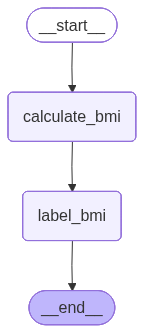

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
### LLM Workflow Example Below ###